<a href="https://colab.research.google.com/github/vitoriaferreirap/DeepLearning/blob/main/PoseEstimation%20_IC/Inferencia_Generalizacao_Analise/Teste2_Avalia%C3%A7%C3%A3oGeneralizacao_SuperAnimal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SuperAnimal no DeepLabCut PyTorch!
- Este notebook (github deeplabcut) demonstra como usar nossos modelos SuperAnimal no DeepLabCut 3.0! Leia mais em Ye et al. Nature Communications 2024 (https://www.nature.com/articles/s41467-024-48792-2) sobre os modelos SuperAnimal disponíveis e acompanhe abaixo!

- Vamos começar: instale a versão mais recente do DeepLabCut no COLAB:
Além disso, certifique-se de estar conectado a uma GPU: vá ao menu, clique em Runtime > Alterar Tipo de Runtime > selecione "GPU"

- Modelo "fundação" que já vem pré-treinado em mais de 45 espécies, incluindo cavalos. (superanimal_quadruped)

-  pode usá-lo sem precisar rotular nada. Ele já entende a anatomia básica de um cavalo e identifica as articulações automaticamente

- teste com mesmos videos do Teste1, mas agora com os animal para esquerda e perto da camera
- HrnetW3

## DeepLabCut ModelZoo (A Ferramenta Mãe)
O **ModelZoo** é como uma "biblioteca pública" de modelos prontos que o DeepLabCut oferece, o SuperAnimal-Quadruped mora aqui dentro.

- SuperAnimal-Quadruped: É o modelo "generalista". Ele foi treinado com milhares de fotos de cavalos, cachorros, elefantes. Ele é ótimo para começar porque já entende o que é um "corpo com quatro patas".

- Versatilidade: Entende cavalo, mas também entende se um cachorro passar atrás.
- Pontos (Labels):	Usa um padrão de pontos que serve para qualquer quadrúpede.
- Precisão	Muito bom para "zero-shot" (quando você não quer rotular nada).

- SuperAnimal é uma vantagem aqui, porque esses modelos foram treinados com uma técnica chamada Video Adaptation. Isso significa que eles são "treinados para entender movimento". Se você der apenas uma imagem, ele funciona bem, mas se você der um vídeo, ele consegue ser ainda mais preciso porque "entende" o contexto do frame anterior.

In [ ]:
!unzip /content/videos.zip -d /content/

In [2]:
!pip install --pre deeplabcut

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 178.0/178.0 kB 13.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.7 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of opencv-python-headless to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.0/137.0 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 119.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 80.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━

In [1]:
# validar uso da GPU
import tensorflow as tf
device_name = tf.test.gpu_device_name()
if "GPU" not in device_name:
    print("GPU não encontrada. Verifique as configurações do notebook.")
else:
    print(f"Sucesso! Conectado à GPU: {device_name}")

Sucesso! Conectado à GPU: /device:GPU:0


In [2]:
# conferir versões
import deeplabcut
import torch

print(f"DeepLabCut versão: {deeplabcut.__version__}")
print(f"PyTorch versão: {torch.__version__}")
print(f"CUDA disponível no PyTorch: {torch.cuda.is_available()}")

Loading DLC 3.0.0rc13...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)
DeepLabCut versão: 3.0.0rc13
PyTorch versão: 2.10.0+cu128
CUDA disponível no PyTorch: True


- Importa as bibliotecas necessárias para o código funcionar, incluindo o DeepLabCut e as funções específicas para o SuperAnimal e análise de imagens/vídeos. É obrigatória para que o Google Colab entenda todos os comandos que executará depois.

In [3]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image

import deeplabcut
import deeplabcut.utils.auxiliaryfunctions as auxiliaryfunctions
from deeplabcut.modelzoo import build_weight_init
from deeplabcut.modelzoo.utils import (
    create_conversion_table,
    read_conversion_table_from_csv,
)
from deeplabcut.modelzoo.video_inference import video_inference_superanimal
from deeplabcut.pose_estimation_pytorch.apis import (
    superanimal_analyze_images,
)
from deeplabcut.utils.pseudo_label import keypoint_matching

- Permite selecionar um arquivo do computador para carregar na memória temporária do Colab e define o caminho desse arquivo na variável video_path.




In [4]:
import glob

# Isso busca todos os arquivos .mp4 dentro da sua pasta 'videos' no Colab
video_path = sorted(glob.glob('/content/videos/*.mp4'))

print(f"Foram encontrados {len(video_path)} vídeos para análise.")
# Exibe os primeiros nomes para conferir
print(video_path[:3])

Foram encontrados 19 vídeos para análise.
['/content/videos/1.mp4', '/content/videos/10.mp4', '/content/videos/11.mp4']


- Configura qual "cérebro" o modelo vai usar. Define o tipo de animal, a arquitetura da rede neural e o detector que encontra o bicho na imagem.


In [5]:
# @markdown ---
# @markdown SuperAnimal Configurations
superanimal_name = "superanimal_quadruped"  # @param ["superanimal_topviewmouse", "superanimal_quadruped"]
model_name = "hrnet_w32"  # @param ["hrnet_w32", "resnet_50"]
detector_name = (
    "fasterrcnn_resnet50_fpn_v2"  # @param ["fasterrcnn_resnet50_fpn_v2", "fasterrcnn_mobilenet_v3_large_fpn"]
)

# @markdown ---
# @markdown What is the maximum number of animals you expect to have in an image
max_individuals = 1  # @param {type:"slider", min:1, max:30, step:1}

Criação de pastas e organização de hierarquia para o drive


In [9]:
import shutil
import os

diretorio_resultados = '/content/resultados_inferencia'
caminho_final_teste = '/content/teste2_avaliacao_generalizacao_superanimal'

# Criar a pasta de resultados e mover os arquivos soltos para ela
if not os.path.exists(diretorio_resultados):
    os.makedirs(diretorio_resultados)

extensoes = ['.h5', '.json', '.mp4']
arquivos_movidos = 0

for arquivo in os.listdir('/content/'):
    if any(arquivo.endswith(ext) for ext in extensoes):
        shutil.move(os.path.join('/content/', arquivo), os.path.join(diretorio_resultados, arquivo))
        arquivos_movidos += 1

print(f"{arquivos_movidos} arquivos movidos para '{diretorio_resultados}'.")

# Criar a pasta de teste e mover a 'resultados_inferencia' para dentro
os.makedirs(caminho_final_teste, exist_ok=True)

rota_destino_final = os.path.join(caminho_final_teste, 'resultados_inferencia')

if os.path.exists(diretorio_resultados):
    # Se já existir uma versão antiga lá dentro, remove para não dar erro
    if os.path.exists(rota_destino_final):
        shutil.rmtree(rota_destino_final)

    # Move a pasta inteira com os arquivos dentro
    shutil.move(diretorio_resultados, caminho_final_teste)
    print(f"Sucesso: Pasta organizada em {rota_destino_final}")

57 arquivos movidos para '/content/resultados_inferencia'.
Sucesso: Pasta organizada em /content/teste2_avaliacao_generalizacao_superanimal/resultados_inferencia



- Função principal:  pega os vídeos e aplica o modelo SuperAnimal neles para identificar os pontos do corpo dos cavalos frame a frame. É esta célula que vai gerar o resultado final para análise.

- Processa a sequência de frames e mostra como o modelo se comporta com o cavalo em movimento. Se usar esta célula como imagem, terá apenas um "retrato" parado, o que é insuficiente para avaliar a generalização em situações reais de uso.

- video_adapt=True: usar o video_adapt=True é como deixar o modelo "estudar" o vídeo antes da prova. Isso mascara as falhas reais do modelo.

- video_adapt=False: usar o video_adapt=False permite que o modelo seja avaliado "zero-shot" (sem qualquer ajuste aos dados a serem analisados) isso é necessário para medir a falha de domínio (domain gap).


In [ ]:
_ = video_inference_superanimal(
    videos=video_path, # local dos dados
    superanimal_name=superanimal_name, # modelo
    model_name=model_name,
    detector_name=detector_name,
    video_adapt=False, # Ao deixar como False, você está testando o modelo "puro" (Zero-shot).
    max_individuals=max_individuals,
    dest_folder="/content/",
    batch_size=16,  # Aumenta a velocidade
)

## Gráfico de Confiança (Likelihood)


Encontrados 19 arquivos para análise.


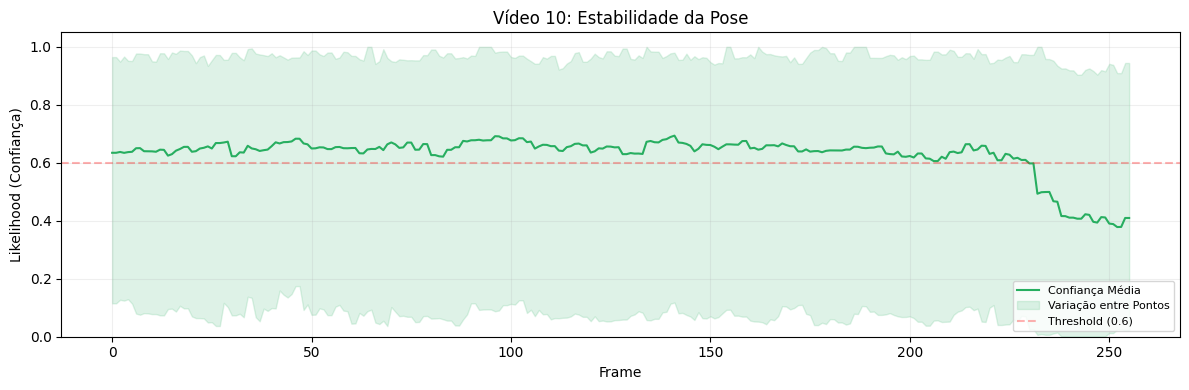

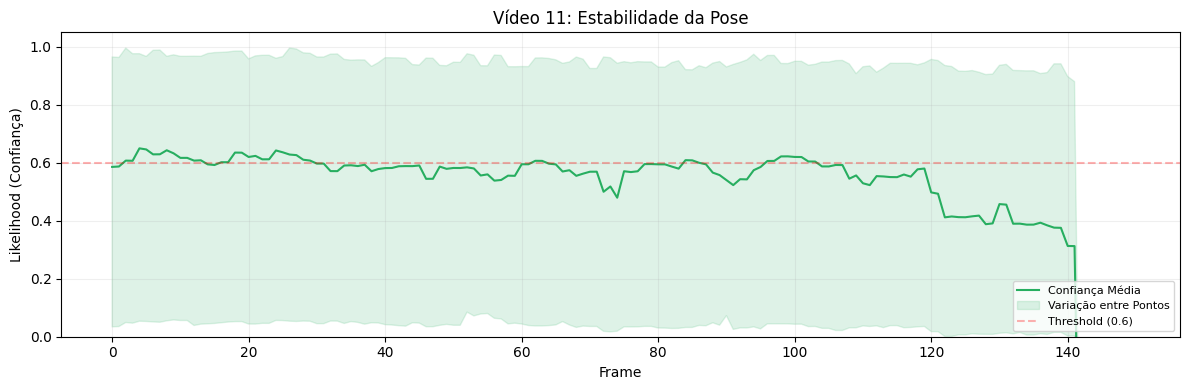

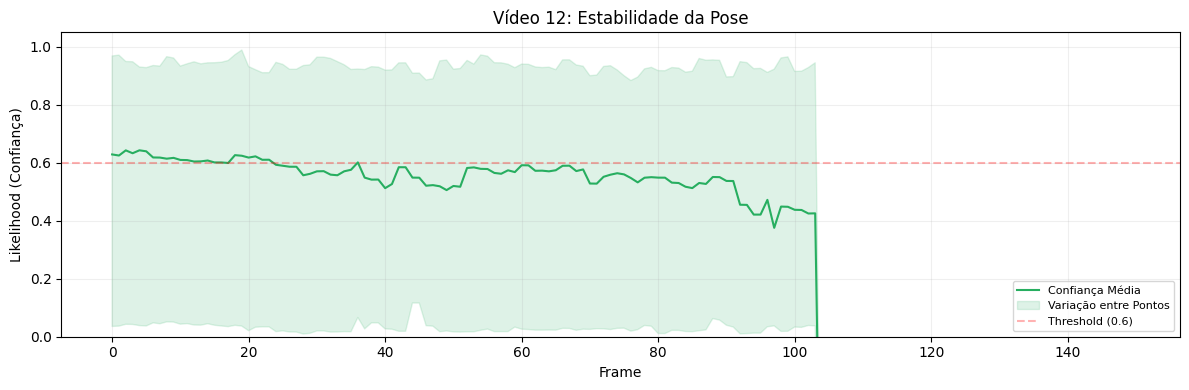

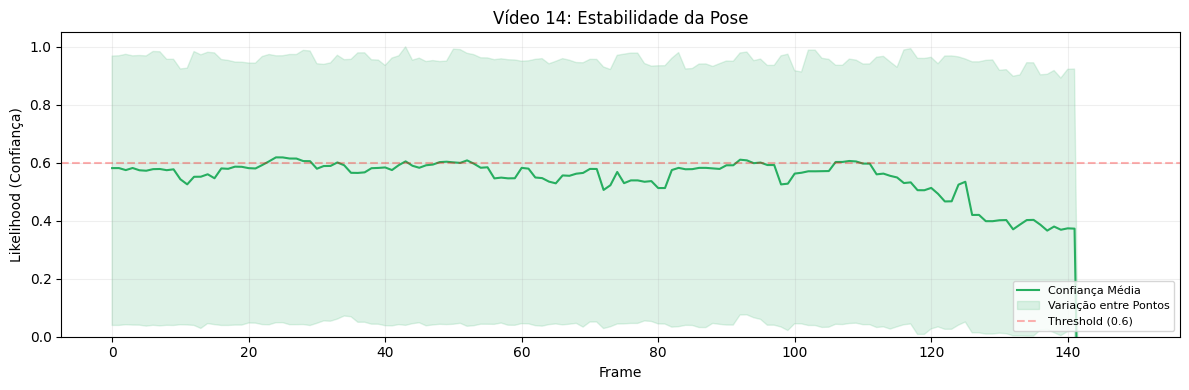

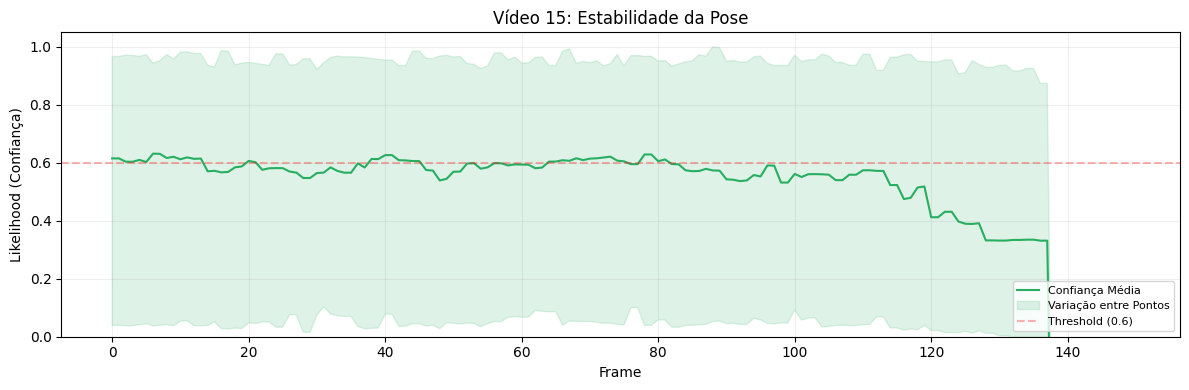

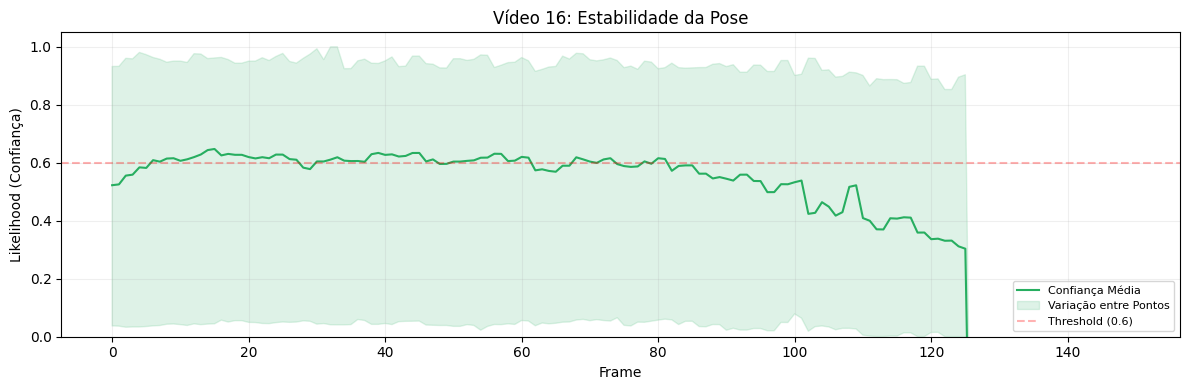

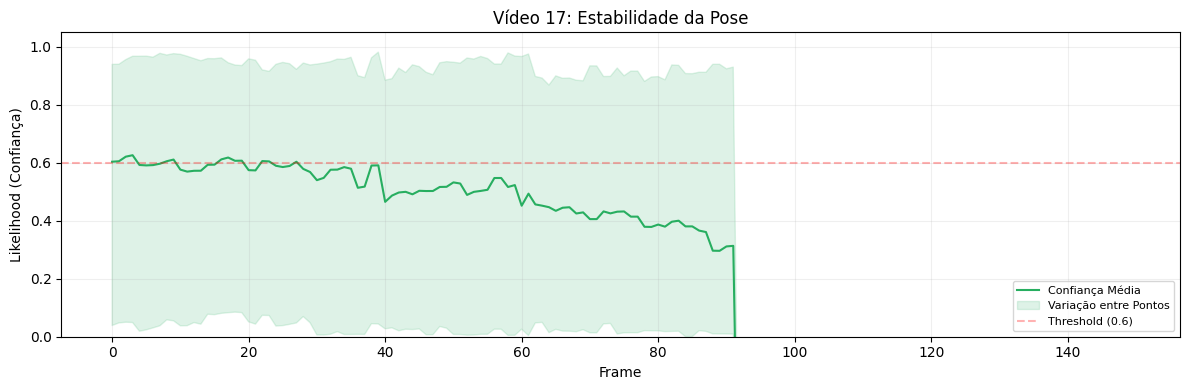

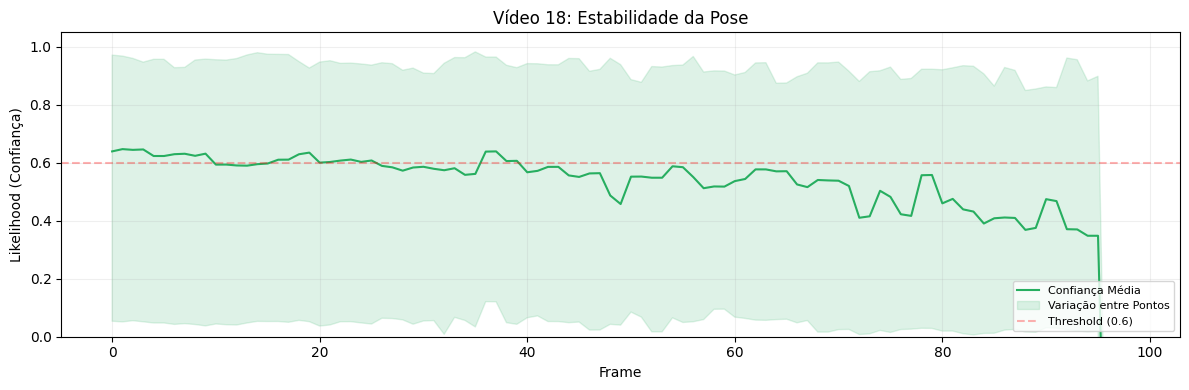

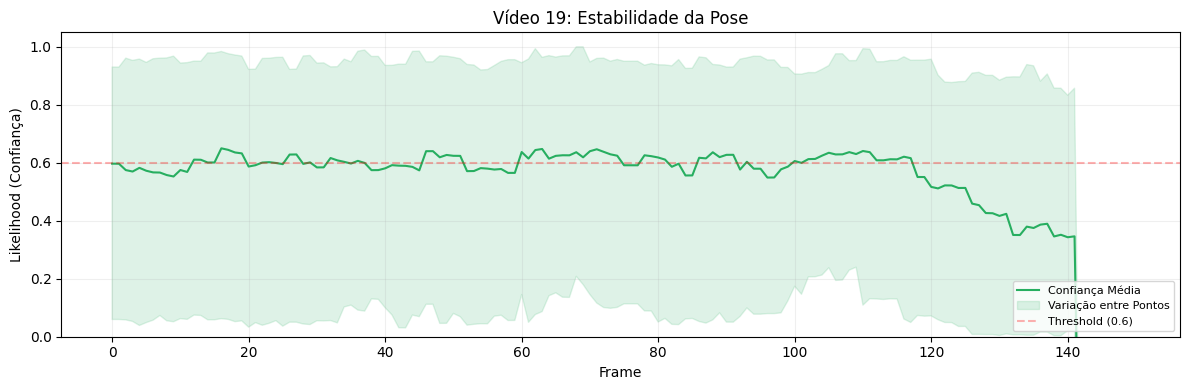

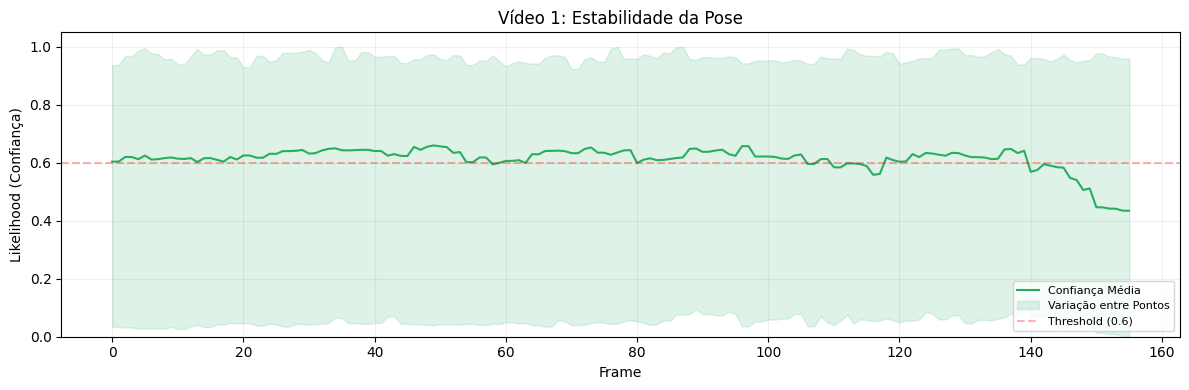

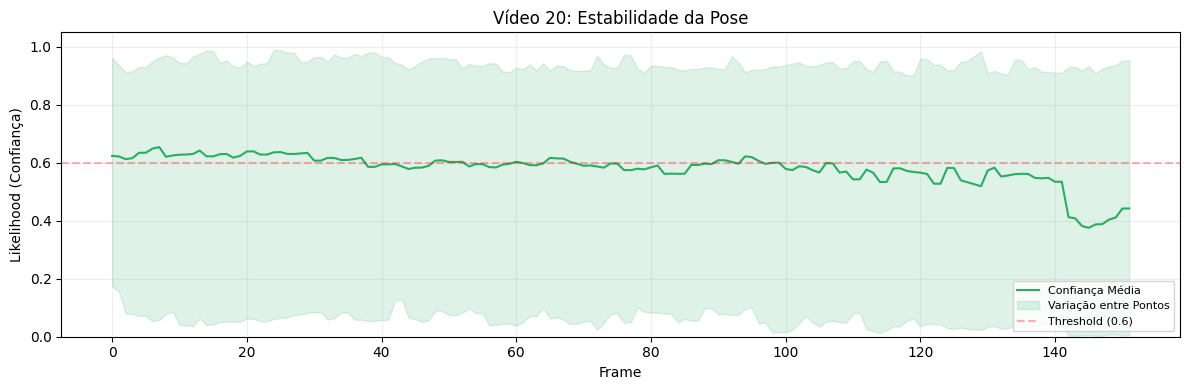

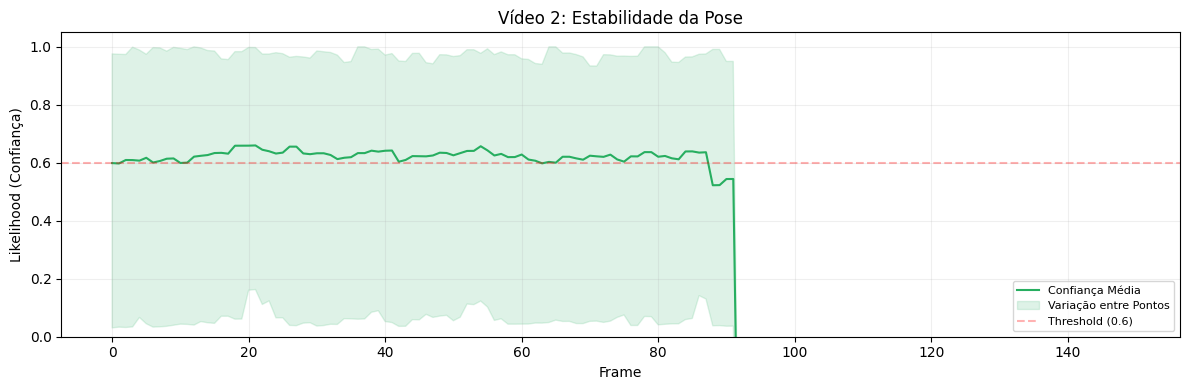

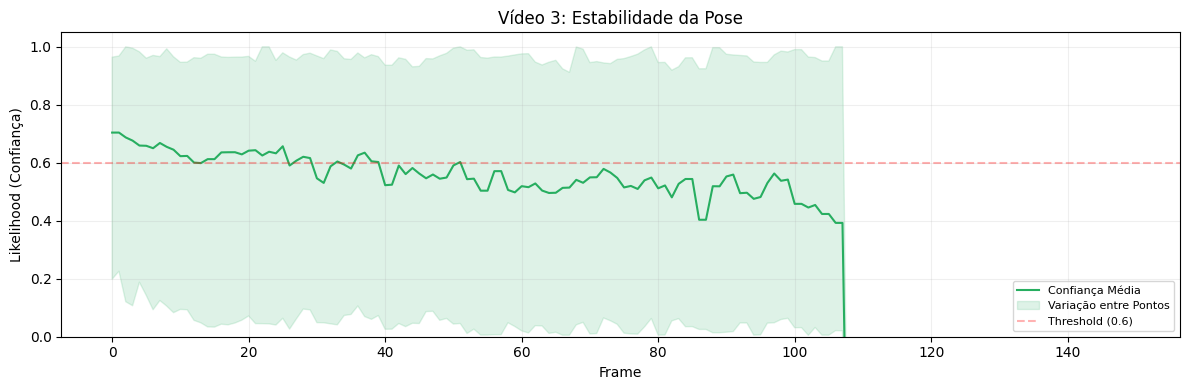

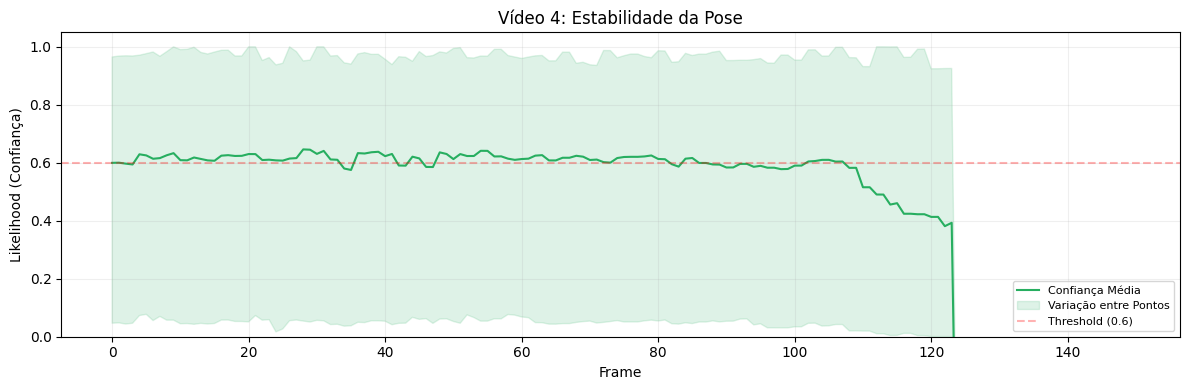

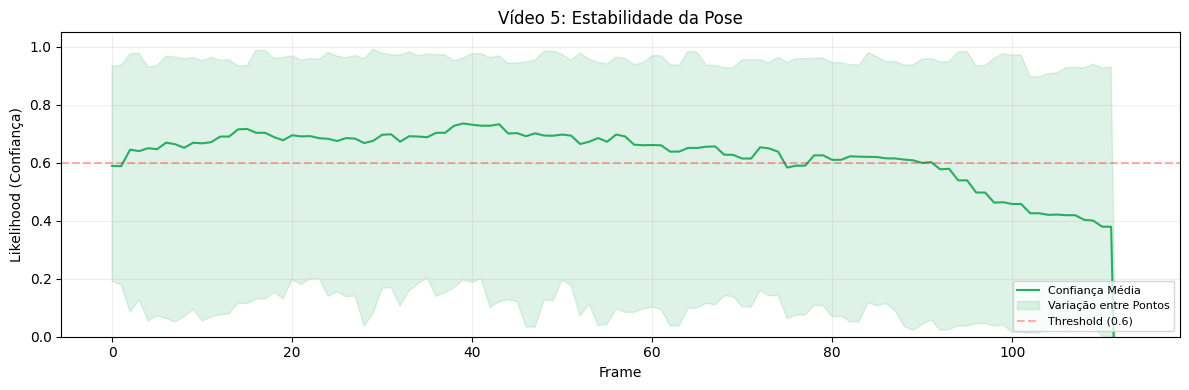

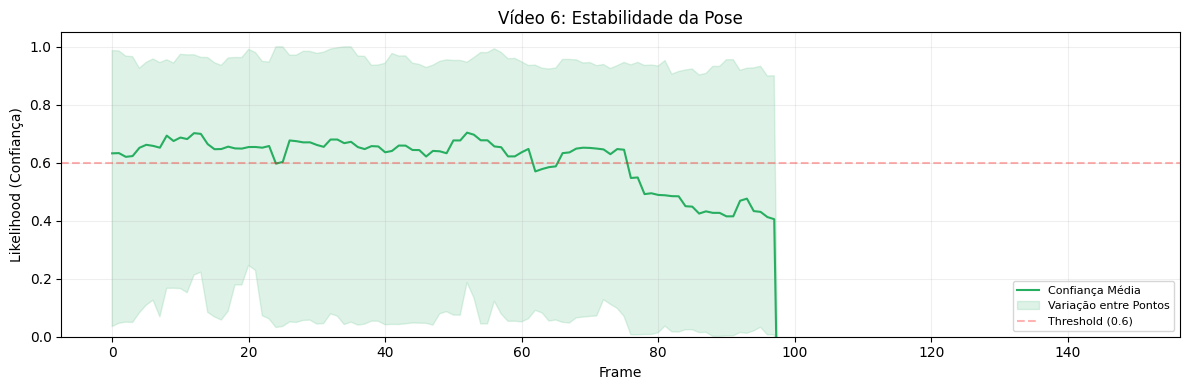

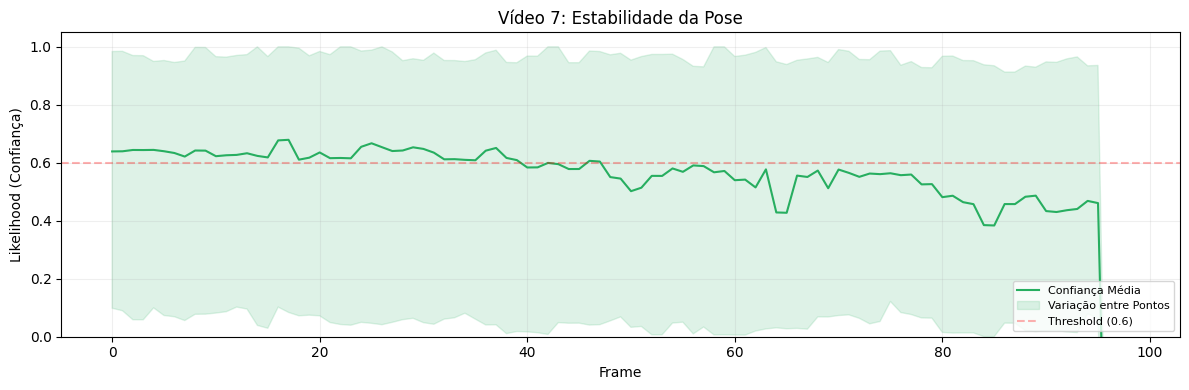

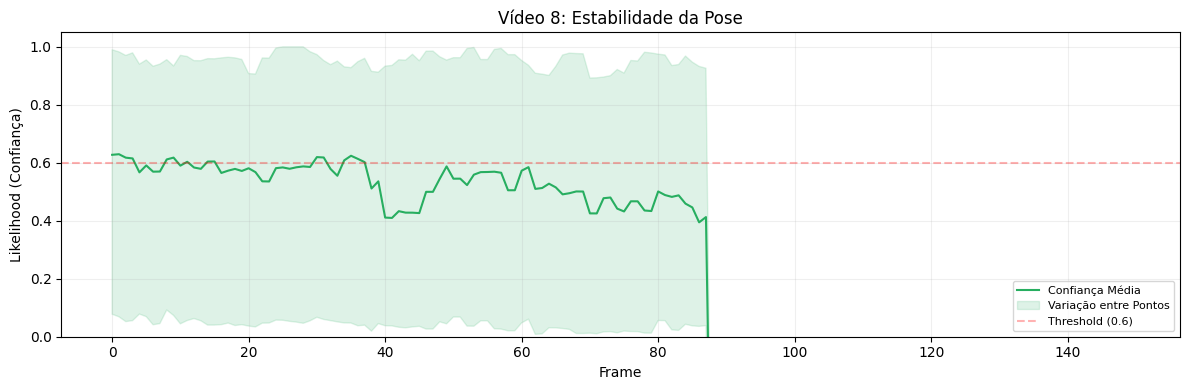

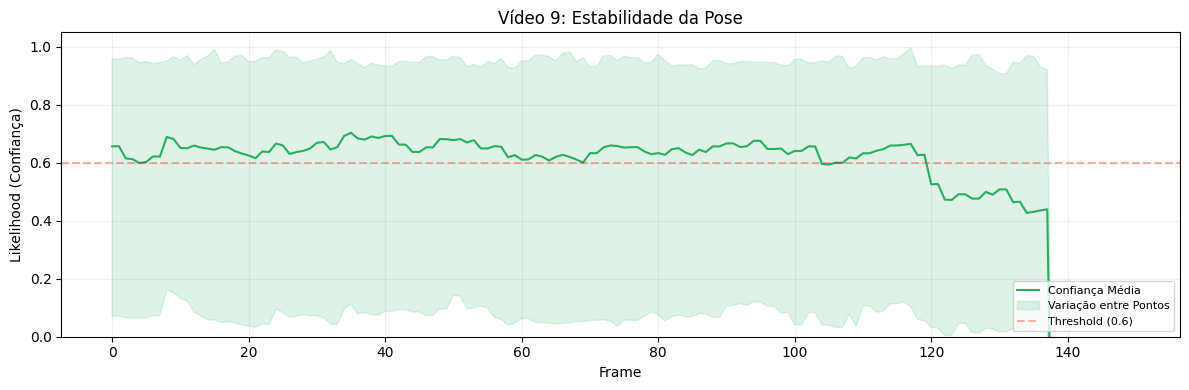

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os

caminho_h5 = '/content/teste2_avaliacao_generalizacao_superanimal/resultados_inferencia'

arquivos = sorted(glob.glob(os.path.join(caminho_h5, '*.h5')))

if len(arquivos) == 0:
    print(f"AVISO: Nenhum arquivo .h5 encontrado em: {caminho_h5}")
else:
    print(f"Encontrados {len(arquivos)} arquivos para análise.")

for arq in arquivos:
    try:
        df = pd.read_hdf(arq)
        confianca_data = df.iloc[:, 2::3]

        media = confianca_data.mean(axis=1)
        min_conf = confianca_data.min(axis=1)
        max_conf = confianca_data.max(axis=1)

        plt.figure(figsize=(12, 4))
        plt.plot(media.values, color='#27ae60', label='Confiança Média', linewidth=1.5)
        plt.fill_between(range(len(media)), min_conf, max_conf, color='#27ae60', alpha=0.15, label='Variação entre Pontos')

        nome_video = os.path.basename(arq).split('_')[0]
        plt.title(f"Vídeo {nome_video}: Estabilidade da Pose", fontsize=12)
        plt.ylabel("Likelihood (Confiança)")
        plt.xlabel("Frame")
        plt.ylim(0, 1.05)
        plt.axhline(y=0.6, color='red', linestyle='--', alpha=0.3, label='Threshold (0.6)')
        plt.legend(loc='lower right', fontsize=8)
        plt.grid(True, alpha=0.2)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f"Erro ao processar o arquivo {os.path.basename(arq)}: {e}")

## Gráfico de Distribuição de Erros (Incerteza Acumulada)
- Esse gráfico usa a técnica de KDE (Kernel Density Estimate), que é a forma correta no PyTorch de visualizar onde o modelo está "errando" mais.

Coletando dados de 19 vídeos para o histograma geral...


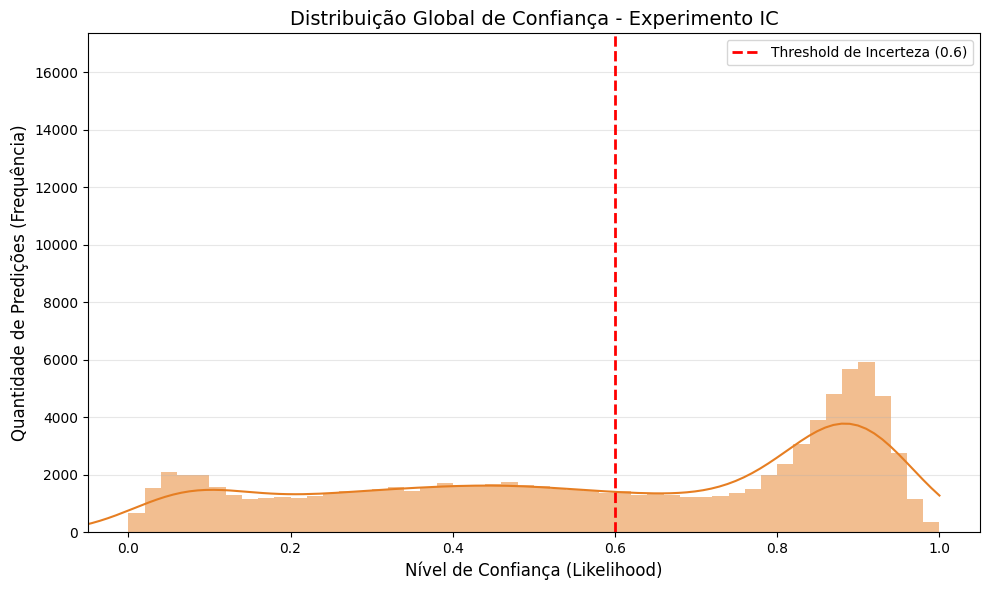


Análise Rápida:
- Média Geral de Confiança: 0.3437
- Porcentagem de predições com incerteza (abaixo de 0.6): 55.79%


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

# Localizar os arquivos
caminho_h5 = '/content/teste2_avaliacao_generalizacao_superanimal/resultados_inferencia'
arquivos = sorted(glob.glob(os.path.join(caminho_h5, '*.h5')))

todas_as_confiancas = []

print(f"Coletando dados de {len(arquivos)} vídeos para o histograma geral...")

for arq in arquivos:
    try:
        df = pd.read_hdf(arq)

        # seleciona apenas as colunas de confiança (índice 2, 5, 8...)
        confianca_data = df.iloc[:, 2::3]

        # Adiciona todos os valores de confiança à nossa lista global
        # .values.flatten() transforma a matriz em uma lista única de números
        todas_as_confiancas.extend(confianca_data.values.flatten())

    except Exception as e:
        print(f"Pulei o arquivo {os.path.basename(arq)} devido ao erro: {e}")

# --- Plotagem da Distribuição ---
plt.figure(figsize=(10, 6))

# Usamos o Seaborn para um visual acadêmico.
# O KDE (a linha suave) ajuda a ver a densidade dos erros.
sns.histplot(todas_as_confiancas, bins=100, kde=True, color='#e67e22', edgecolor='none')

# Linha de corte científica (Threshold de 0.6)
plt.axvline(0.6, color='red', linestyle='--', linewidth=2, label='Threshold de Incerteza (0.6)')

plt.title("Distribuição Global de Confiança - Experimento IC", fontsize=14)
plt.xlabel("Nível de Confiança (Likelihood)", fontsize=12)
plt.ylabel("Quantidade de Predições (Frequência)", fontsize=12)
plt.xlim(-0.05, 1.05)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Resumo estatístico para o seu relatório
import numpy as np
conf_array = np.array(todas_as_confiancas)
abaixo_limite = (conf_array < 0.6).sum() / len(conf_array) * 100
print(f"\nAnálise Rápida:")
print(f"- Média Geral de Confiança: {np.mean(conf_array):.4f}")
print(f"- Porcentagem de predições com incerteza (abaixo de 0.6): {abaixo_limite:.2f}%")

In [15]:
# Upload para o Google Drive
from google.colab import drive
import os
import shutil

# Montar o Google Drive
drive.mount('/content/drive')

# Caminho da pasta de destino no seu Drive
# Ajustei o nome para backup_ic conforme solicitado
drive_path = '/content/drive/MyDrive/Beckup_IC/FASE_2_IC/Aprendizado_Generalização'
nova_pasta_nome = 'teste2_avaliacao_generalizacao_superanimal'
caminho_final_drive = os.path.join(drive_path, nova_pasta_nome)

if not os.path.exists(drive_path):
    print(f" A pasta 'Beckup_IC' não foi encontrada na raiz do seu Drive. Criando-a agora...")
    os.makedirs(drive_path, exist_ok=True)

# Criar a pasta do teste dentro do backup
os.makedirs(caminho_final_drive, exist_ok=True)

# Copiar os arquivos do Colab para o Drive
origem_local = '/content/teste2_avaliacao_generalizacao_superanimal'

print(f"Iniciando upload para: {caminho_final_drive}...")

# Usamos copytree para enviar a pasta inteira
for item in os.listdir(origem_local):
    s = os.path.join(origem_local, item)
    d = os.path.join(caminho_final_drive, item)
    if os.path.isdir(s):
        if os.path.exists(d):
            shutil.rmtree(d)
        shutil.copytree(s, d)
    else:
        shutil.copy2(s, d)

print("Backup concluído!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Iniciando upload para: /content/drive/MyDrive/Beckup_IC/FASE_2_IC/Aprendizado_Generalização/teste2_avaliacao_generalizacao_superanimal...
Backup concluído!
